In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)
m=50
x=2*np.random.rand(m,1)
y=(4+3*x+np.random.randn(m,1)).ravel()

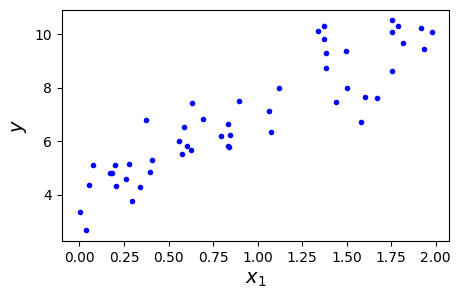

In [6]:
plt.figure(figsize=(5,3))
plt.plot(x,y,'bo',markersize=3)
plt.xlabel('$x_1$',fontsize=14)
plt.ylabel('$y$',fontsize=14)
plt.show()

In [17]:
from sklearn.svm import LinearSVR

svm_reg=LinearSVR(epsilon=0.5,random_state=1,dual=True)
svm_reg.fit(x,y)
svm_reg.intercept_, svm_reg.coef_

(array([3.82895689]), array([3.18608831]))

In [18]:
svm_reg.score(x,y)

0.813787675910222

In [19]:
def find_support_vectors(svm_reg,x,y,epsilon):
    y_pred=svm_reg.predict(x)
    off_margin=(np.abs(y-y_pred)>=epsilon)
    return np.argwhere(off_margin)

In [20]:
def plot_svm_regression(model, x, y, epsilon, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = model.predict(x1s)

    plt.plot(x1s, y_pred, 'r-', linewidth=2, label='$\hat{y}$')
    plt.plot(x1s, y_pred + epsilon, 'k--')
    plt.plot(x1s, y_pred - epsilon, 'k--')

    model.support_ = find_support_vectors(model, x, y, epsilon)
    plt.scatter(x[model.support_], y[model.support_], c='red', s=50, alpha=0.3)

    plt.plot(x, y, 'bo', markersize=3)
    plt.xlabel('$x_1$', fontsize=14)
    plt.ylabel('$y$', fontsize=14, rotation=0)
    plt.legend(loc='lower right')

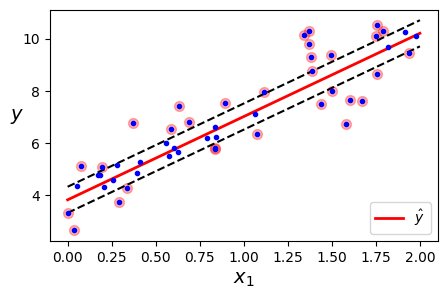

In [21]:
plt.figure(figsize=(5,3))
plot_svm_regression(svm_reg,x,y,0.5,axes=[0,2,3,11])
plt.show()

In [23]:
from sklearn.linear_model import SGDRegressor

sgd_reg=SGDRegressor(loss='epsilon_insensitive',epsilon=0.5,random_state=1)
sgd_reg.fit(x,y)
sgd_reg.intercept_, sgd_reg.coef_

(array([3.70372653]), array([3.36479139]))

In [24]:
sgd_reg.score(x,y)

0.8115955618208129

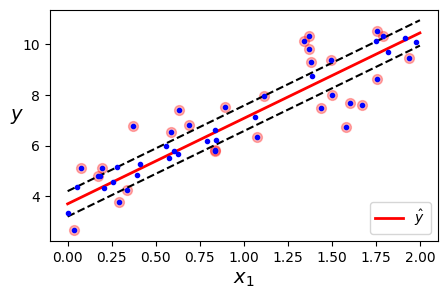

In [25]:
plt.figure(figsize=(5,3))
plot_svm_regression(sgd_reg,x,y,0.5,axes=[0,2,3,11])
plt.show()

In [26]:
from sklearn.svm import SVR

svr_reg=SVR(kernel='linear',epsilon=0.5)
svr_reg.fit(x,y)
svr_reg.intercept_, svr_reg.coef_

(array([4.21115491]), array([[2.91591784]]))

In [27]:
svr_reg.score(x,y)

0.8134889655563093

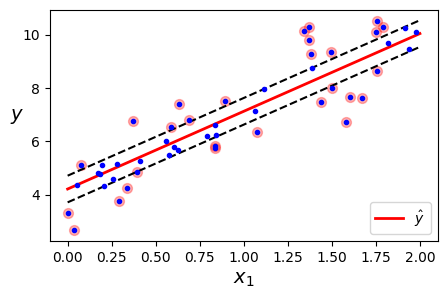

In [28]:
plt.figure(figsize=(5,3))
plot_svm_regression(svr_reg,x,y,0.5,axes=[0,2,3,11])
plt.show()

In [29]:
np.random.seed(1)
m=100
x=2*np.random.rand(m,1)-1
y=(0.2+0.1*x+0.5*x**2+np.random.randn(m,1)/10).ravel()

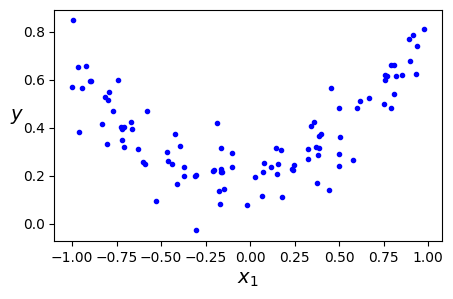

In [30]:
plt.figure(figsize=(5,3))
plt.plot(x,y,'bo',markersize=3)
plt.xlabel('$x_1$',fontsize=14)
plt.ylabel('$y$',fontsize=14,rotation=0)
plt.show()

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

In [32]:
poly_svm_reg = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('poly_svm', LinearSVR(max_iter=10000, epsilon=0.1, random_state=1))
])

In [33]:
poly_svm_reg.fit(x, y)
poly_svm_reg['poly_svm'].intercept_, \
poly_svm_reg['poly_svm'].coef_

(array([0.37849953]), array([0.03567448, 0.16274833]))

In [34]:
poly_svm_reg.score(x, y)

0.7690321422676615

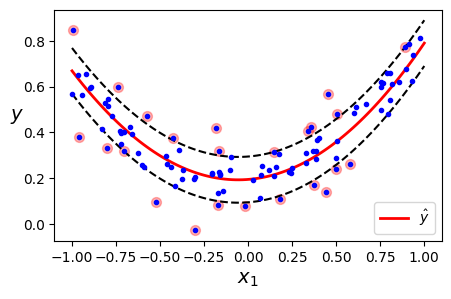

In [35]:
plt.figure(figsize=(5,3))
plot_svm_regression(poly_svm_reg,x,y,0.1,[-1,1,0,1])
plt.show()

In [37]:
poly_sgd_reg = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('poly_sgd', SGDRegressor(loss='epsilon_insensitive', epsilon=0.1, random_state=1))
])

poly_sgd_reg.fit(x, y)
poly_sgd_reg['poly_sgd'].intercept_, \
poly_sgd_reg['poly_sgd'].coef_

(array([0.37549958]), array([0.04139847, 0.15873503]))

In [38]:
poly_sgd_reg.score(x, y)

0.7724751759150993

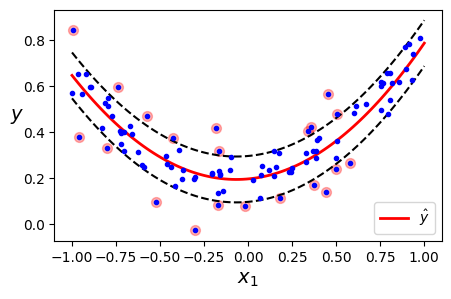

In [39]:
plt.figure(figsize=(5,3))
plot_svm_regression(poly_sgd_reg,x,y,0.1,[-1,1,0,1])
plt.show()

In [40]:
poly_svr_reg=SVR(kernel='poly',degree=2,epsilon=0.1,gamma=1)
poly_svr_reg.fit(x,y)

SVR(degree=2, gamma=1, kernel='poly')

In [41]:
poly_svr_reg.score(x,y)

0.7019128605564215

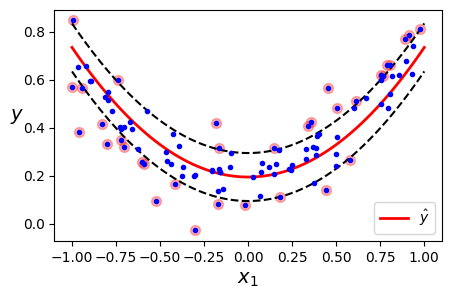

In [43]:
plt.figure(figsize=(5,3))
plot_svm_regression(poly_svr_reg,x,y,0.1,[-1,1,0,1])
plt.show()

In [44]:
rbf_svr_reg=SVR(kernel='rbf',degree=2,epsilon=0.1,gamma=1)
rbf_svr_reg.fit(x,y)

SVR(degree=2, gamma=1)

In [45]:
rbf_svr_reg.score(x,y)

0.7645639795714291

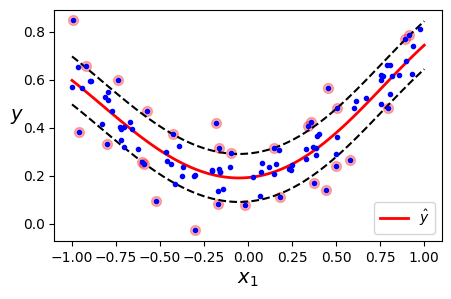

In [46]:
plt.figure(figsize=(5,3))
plot_svm_regression(rbf_svr_reg,x,y,0.1,[-1,1,0,1])
plt.show()